Data shape: (112120, 12)

Disease counts:
 No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


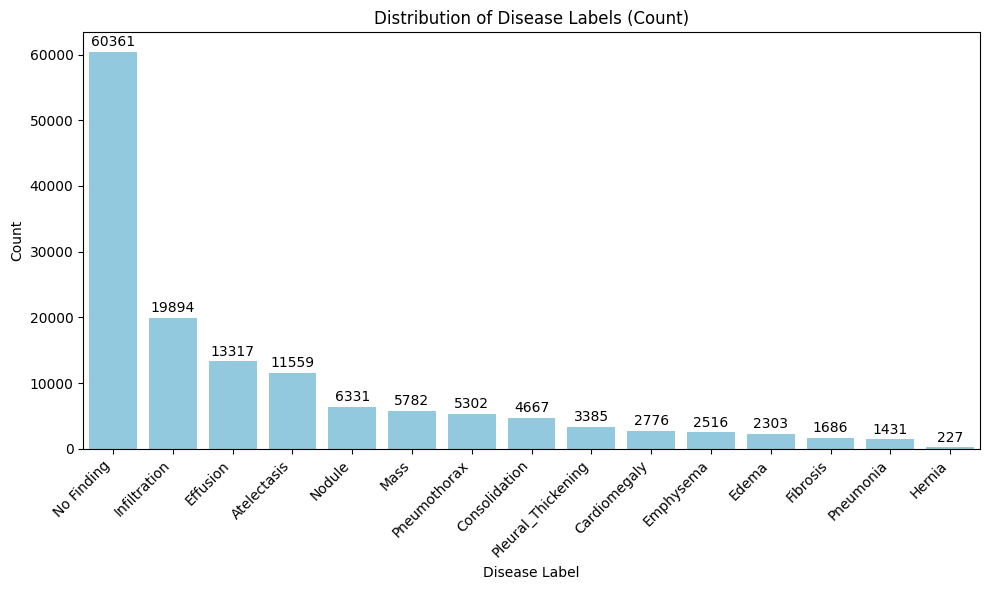

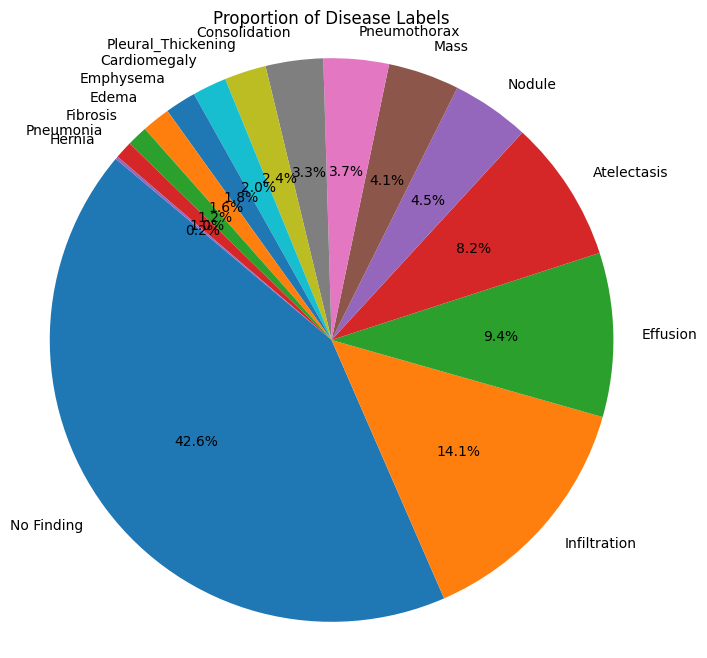


Follow-up # distribution:
 Follow-up #
0      30805
1      13302
2       9189
3       7089
4       5759
       ...  
179        1
180        1
181        1
182        1
183        1
Name: count, Length: 184, dtype: int64


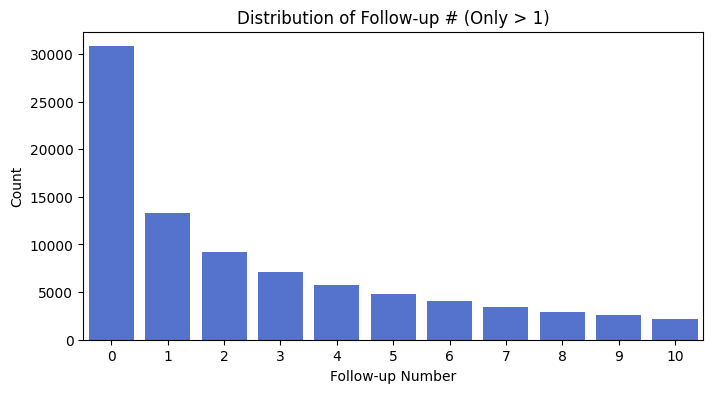


Number of unique patients: 30805

Gender distribution:
 Patient Gender
M    63340
F    48780
Name: count, dtype: int64


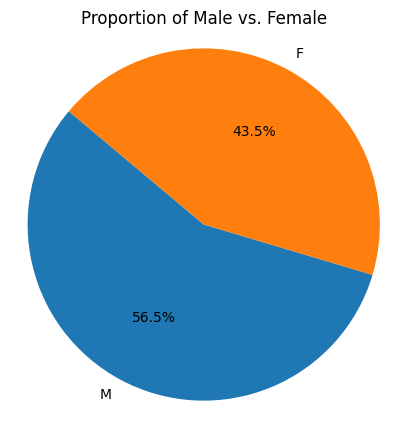

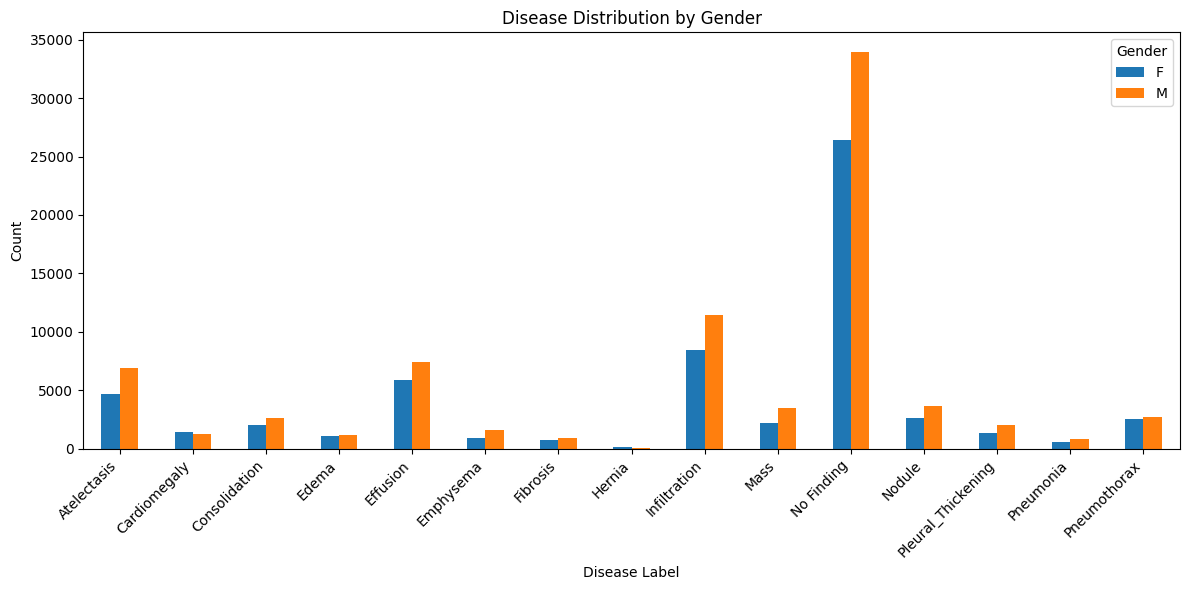

DiseaseLabel
Hernia                63.211454
Fibrosis              52.706999
Pleural_Thickening    50.527917
Atelectasis           50.495458
Emphysema             50.324324
Effusion              49.771195
Nodule                49.476228
Mass                  48.816327
Cardiomegaly          47.268012
Consolidation         46.654810
Pneumothorax          46.486420
Infiltration          46.200814
No Finding            45.766405
Edema                 45.578810
Pneumonia             44.927324
Name: Patient Age, dtype: float64


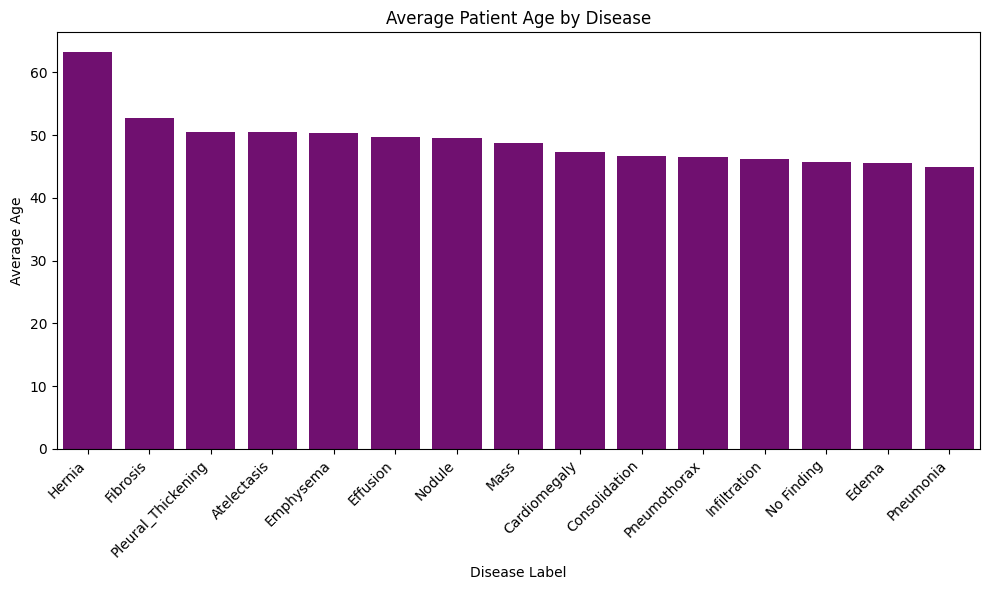

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


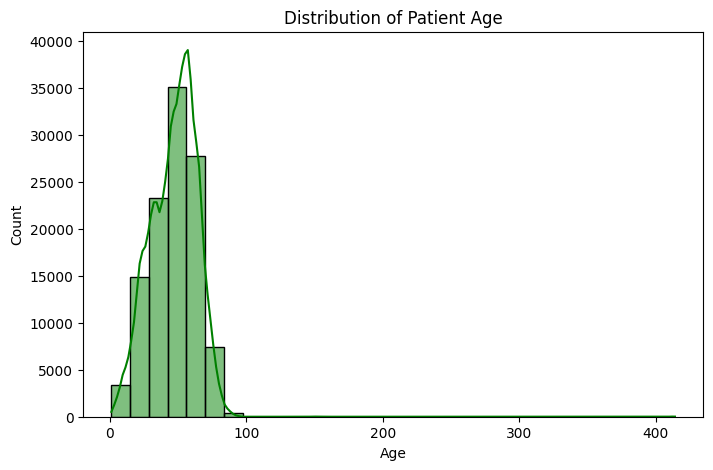

Descriptive Statistics:
          Patient Age    Follow-up #
count  112120.000000  112120.000000
mean       46.901463       8.573751
std        16.839923      15.406320
min         1.000000       0.000000
25%        35.000000       0.000000
50%        49.000000       3.000000
75%        59.000000      10.000000
max       414.000000     183.000000


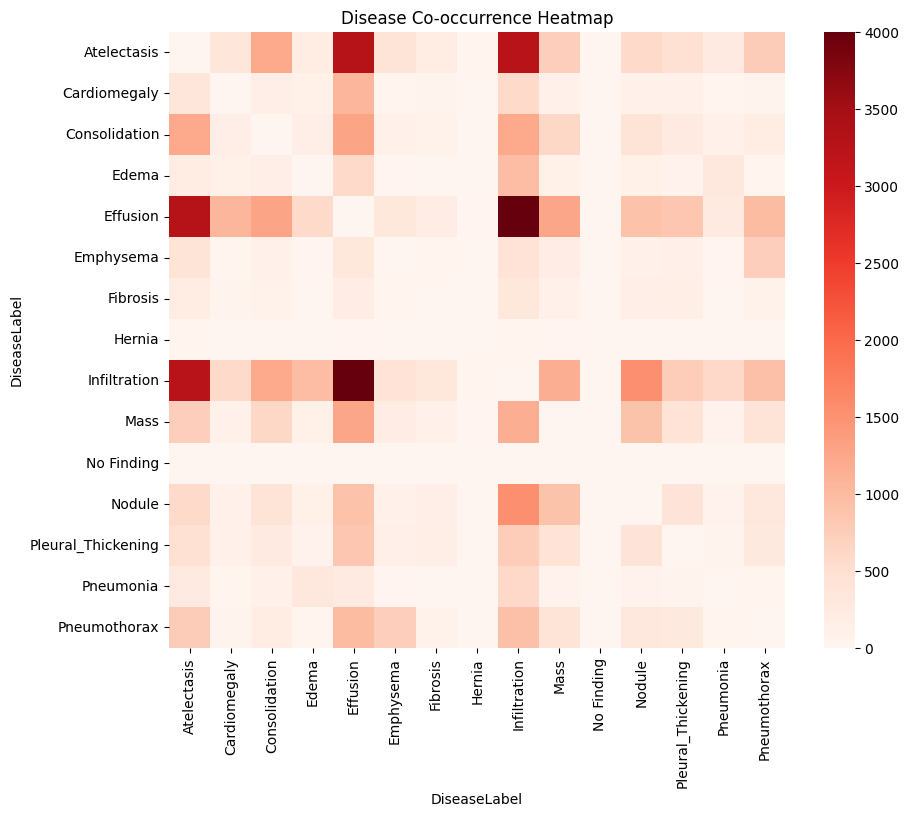

Pure 'No Finding' rows: 60361
'No Finding' combined with other disease: 0


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
import numpy as np

# ----------------------------------------------------------------------------
# 1) READ THE CSV FILE
# ----------------------------------------------------------------------------

metadata_path = "/kaggle/input/data/Data_Entry_2017.csv"  # Adjust if needed
df = pd.read_csv(metadata_path)




# train_val_path = "/kaggle/input/data/train_val_list.txt"
# with open(train_val_path, "r") as f:
#     train_val_files = f.read().splitlines()

# # Now filter the DataFrame to include only rows where "Image Index" is in train_val_files
# df = df[df["Image Index"].isin(train_val_files)]




# test_list_path = "/kaggle/input/data/test_list.txt"
# with open(test_list_path, "r") as f:
#     test_list_list = f.read().splitlines()

# # Now filter the DataFrame to include only rows where "Image Index" is in train_val_files
# df = df[df["Image Index"].isin(test_list_list)]


print("Data shape:", df.shape)

# ----------------------------------------------------------------------------
# 2) PARSE MULTI-LABEL DISEASE STRINGS INTO INDIVIDUAL LABELS
# ----------------------------------------------------------------------------

all_diseases = []
for finding_str in df["Finding Labels"]:
    # Split on '|' to handle multi-label
    diseases_in_row = finding_str.split("|")
    all_diseases.extend(diseases_in_row)

# Count occurrences of each disease label
disease_counts = Counter(all_diseases)

# Convert to a sorted Pandas series
disease_counts_series = pd.Series(disease_counts).sort_values(ascending=False)
print("\nDisease counts:\n", disease_counts_series)

# ----------------------------------------------------------------------------
# 3) CREATE A BAR CHART OF DISEASE COUNTS (with labels above bars)
# ----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=disease_counts_series.index, y=disease_counts_series.values, color='skyblue')
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability
plt.title("Distribution of Disease Labels (Count)")
plt.ylabel("Count")
plt.xlabel("Disease Label")

# Add count labels on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        xytext=(0, 2),
        textcoords='offset points'  # Slight offset above the bar
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 4) CREATE A PIE CHART OF DISEASE PROPORTIONS
# ----------------------------------------------------------------------------

plt.figure(figsize=(8, 8))
plt.pie(disease_counts_series.values, labels=disease_counts_series.index,
        autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Disease Labels")
plt.axis('equal')
plt.show()

# ----------------------------------------------------------------------------
# 5) DISTRIBUTION OF THE NUMBER OF FOLLOW-UPS (only show follow-ups > 1)
# ----------------------------------------------------------------------------

follow_up_counts = df["Follow-up #"].value_counts().sort_index()
print("\nFollow-up # distribution:\n", follow_up_counts)

# Filter to keep only rows where follow-up # > 1
follow_up_counts_filtered = follow_up_counts[
    (follow_up_counts.index >= 0) & (follow_up_counts.index <= 10) & (follow_up_counts >= 0)
]

# Plot using the filtered Series
plt.figure(figsize=(8, 4))
sns.barplot(
    x=follow_up_counts_filtered.index,
    y=follow_up_counts_filtered.values,
    color='royalblue'
)
plt.title("Distribution of Follow-up # (Only > 1)")
plt.xlabel("Follow-up Number")
plt.ylabel("Count")
plt.show()

# ----------------------------------------------------------------------------
# 6) NUMBER OF UNIQUE PATIENTS
# ----------------------------------------------------------------------------

unique_patients_count = df["Patient ID"].nunique()
print("\nNumber of unique patients:", unique_patients_count)

# ----------------------------------------------------------------------------
# 7) DISTRIBUTION OF MALE AND FEMALE
# ----------------------------------------------------------------------------

gender_counts = df["Patient Gender"].value_counts()
print("\nGender distribution:\n", gender_counts)

plt.figure(figsize=(5, 5))
plt.pie(gender_counts.values, labels=gender_counts.index,
        autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Male vs. Female")
plt.axis('equal')
plt.show()

# ----------------------------------------------------------------------------
# 8) BAR CHART FOR THE DISTRIBUTION OF MALE & FEMALE FOR EACH DISEASE
# ----------------------------------------------------------------------------

exploded_df = (
    df.assign(DiseaseLabel=df["Finding Labels"].str.split("|"))
      .explode("DiseaseLabel")
)

disease_gender_counts = exploded_df.groupby(["DiseaseLabel", "Patient Gender"]).size().reset_index(name='Count')
disease_gender_pivot = disease_gender_counts.pivot(index="DiseaseLabel", columns="Patient Gender", values="Count").fillna(0)

disease_gender_pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Disease Distribution by Gender")
plt.xlabel("Disease Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 9) DISEASES VS AGE
# ----------------------------------------------------------------------------

# Explode the multi-label 'Finding Labels' column
exploded_df = (
    df.assign(DiseaseLabel=df["Finding Labels"].str.split("|"))
      .explode("DiseaseLabel")
)

# Compute average age by disease
disease_age = exploded_df.groupby("DiseaseLabel")["Patient Age"].mean().sort_values(ascending=False)
print(disease_age)

# Plot as bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=disease_age.index, y=disease_age.values, color='purple')
plt.xticks(rotation=45, ha='right')
plt.title("Average Patient Age by Disease")
plt.ylabel("Average Age")
plt.xlabel("Disease Label")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 10) AGE DISTRIBUTION
# ----------------------------------------------------------------------------

# Basic Age Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Patient Age"], bins=30, kde=True, color='green')
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ----------------------------------------------------------------------------
# 11) DESCRIPTIVE STATISTICS FOR AGE AND FOLLOW UP #
# ----------------------------------------------------------------------------

# 1) Calculate descriptive stats for "Patient Age" and "Follow-up #"
stats = df[["Patient Age", "Follow-up #"]].describe()
print("Descriptive Statistics:\n", stats)

# 2) Extract specific stats
mean_age       = stats.loc["mean", "Patient Age"]
std_age        = stats.loc["std", "Patient Age"]
min_age        = stats.loc["min", "Patient Age"]
max_age        = stats.loc["max", "Patient Age"]

mean_followup  = stats.loc["mean", "Follow-up #"]
std_followup   = stats.loc["std", "Follow-up #"]
min_followup   = stats.loc["min", "Follow-up #"]
max_followup   = stats.loc["max", "Follow-up #"]

# ----------------------------------------------------------------------------
# 12) CO OCCURENCE COUNTS FOR EACH PAIR OF DISEASES
# ----------------------------------------------------------------------------

# Explode multi-label
exploded_df = (
    df.assign(DiseaseLabel=df["Finding Labels"].str.split("|"))
      .explode("DiseaseLabel")
)

# We want a multi-hot pivot: row=Image Index, columns=Disease
multi_hot = pd.crosstab(exploded_df["Image Index"], exploded_df["DiseaseLabel"])

# Calculate co-occurrence by taking the dot product of multi_hot with itself
co_occ_matrix = np.dot(multi_hot.T, multi_hot)  # disease x disease matrix
co_occ_df = pd.DataFrame(co_occ_matrix, index=multi_hot.columns, columns=multi_hot.columns)

# Fill diagonal with 0 if you don't want the self-count
np.fill_diagonal(co_occ_df.values, 0)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(co_occ_df, cmap="Reds", square=True)
plt.title("Disease Co-occurrence Heatmap")
plt.show()

# ----------------------------------------------------------------------------
# 13) NO FINDING ANALYSIS
# ----------------------------------------------------------------------------

# Distinguish between purely "No Finding" vs "No Finding + something else"
df["IsPureNoFinding"] = df["Finding Labels"].apply(
    lambda x: x.strip() == "No Finding"
)

pure_no_finding_count = df["IsPureNoFinding"].sum()
multiple_labels_with_no_finding = (
    df["Finding Labels"].str.contains("No Finding") & df["Finding Labels"].str.contains("\|")
).sum()

print("Pure 'No Finding' rows:", pure_no_finding_count)
print("'No Finding' combined with other disease:", multiple_labels_with_no_finding)

In [17]:
import pandas as pd
import torch
import torch.nn as nn

# -----------------------------------------------------------
# 1. Extract the unique set of classes from "Finding Labels"
# -----------------------------------------------------------
unique_labels = set()
for labels_str in df["Finding Labels"]:
    # Split the string by "|" since an image may have multiple labels.
    labels = labels_str.split("|")
    unique_labels.update(labels)

# Convert the set to a sorted list for consistency.
unique_labels = sorted(unique_labels)
print("Unique labels found:", unique_labels)

# -----------------------------------------------------------
# 2. Compute pos_counts and neg_counts for each class
# -----------------------------------------------------------
# Total number of images in the dataset
total_images = len(df)

# Initialize dictionary to hold counts for each class
pos_counts = {cls: 0 for cls in unique_labels}

# Iterate over each row to update positive counts.
for labels_str in df["Finding Labels"]:
    labels = labels_str.split("|")
    for cls in unique_labels:
        if cls in labels:
            pos_counts[cls] += 1

# Create tensors for positive and negative counts.
# For each class: neg_counts = total_images - pos_counts
pos_counts_tensor = torch.tensor([pos_counts[cls] for cls in unique_labels], dtype=torch.float)
neg_counts_tensor = torch.tensor([total_images - pos_counts[cls] for cls in unique_labels], dtype=torch.float)

# Compute the pos_weight for each class.
# This weight boosts the loss for the positive class when the class is underrepresented.
pos_weight = neg_counts_tensor / pos_counts_tensor
print("Positive weights for each class:", pos_weight)

Unique labels found: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Positive weights for each class: tensor([  8.6998,  39.3890,  23.0240,  47.6843,   7.4193,  43.5628,  65.5006,
        492.9207,   4.6359,  18.3912,   0.8575,  16.7097,  32.1226,  77.3508,
         20.1467])


In [6]:
# We'll focus on these two columns:
cols = ["Patient Age", "Follow-up #"]

# =============================================================================
# (2) Calculate IQR bounds for Patient Age
# =============================================================================
Q1_age = df["Patient Age"].quantile(0.25)
Q3_age = df["Patient Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

age_lower_bound = Q1_age - 1.5 * IQR_age
age_upper_bound = Q3_age + 1.5 * IQR_age

# =============================================================================
# (3) Calculate IQR bounds for Follow-up #
# =============================================================================
Q1_follow = df["Follow-up #"].quantile(0.25)
Q3_follow = df["Follow-up #"].quantile(0.75)
IQR_follow = Q3_follow - Q1_follow

follow_lower_bound = Q1_follow - 1.5 * IQR_follow
follow_upper_bound = Q3_follow + 1.5 * IQR_follow

# =============================================================================
# (4) Create masks for each column
# =============================================================================
mask_age = (df["Patient Age"] >= age_lower_bound) & (df["Patient Age"] <= age_upper_bound)
mask_follow = (df["Follow-up #"] >= follow_lower_bound) & (df["Follow-up #"] <= follow_upper_bound)

# =============================================================================
# (5) Identify which rows are outliers in Age or Follow-up
# =============================================================================
outliers_age = df[~mask_age]             # rows failing age filter
outliers_follow = df[~mask_follow]       # rows failing follow-up filter

num_outliers_age = outliers_age.shape[0]
num_outliers_follow = outliers_follow.shape[0]

# =============================================================================
# (6) Keep only rows passing BOTH filters
# =============================================================================
final_mask = mask_age & mask_follow
df_cleaned = df[final_mask]

# =============================================================================
# (7) Summarize results
# =============================================================================
original_count = df.shape[0]
final_count = df_cleaned.shape[0]
total_removed = original_count - final_count

print("\n--- Outlier Removal Summary ---")
print(f"Original number of rows: {original_count}")
print(f"Outliers in Age: {num_outliers_age}")
print(f"Outliers in Follow-up #: {num_outliers_follow}")
print(f"Total rows after removing both Age and Follow-up outliers: {final_count}")
print(f"Total rows removed: {total_removed}")


--- Outlier Removal Summary ---
Original number of rows: 112120
Outliers in Age: 16
Outliers in Follow-up #: 10182
Total rows after removing both Age and Follow-up outliers: 101924
Total rows removed: 10196


In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

###############################
# 1. LOAD AND CLEAN METADATA  #
###############################

# Define paths (adjust these paths as needed)
metadata_path = "/kaggle/input/data/Data_Entry_2017.csv"
train_val_list_path = "/kaggle/input/data/train_val_list.txt"
test_list_path = "/kaggle/input/data/test_list.txt"

# Load the metadata CSV file.
df = pd.read_csv(metadata_path)

# --- Outlier Removal on "Patient Age" and "Follow-up #" ---

# Focus on these two columns.
cols = ["Patient Age", "Follow-up #"]

# Calculate IQR bounds for Patient Age
Q1_age = df["Patient Age"].quantile(0.25)
Q3_age = df["Patient Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age
age_lower_bound = Q1_age - 1.5 * IQR_age
age_upper_bound = Q3_age + 1.5 * IQR_age

# Calculate IQR bounds for Follow-up #
Q1_follow = df["Follow-up #"].quantile(0.25)
Q3_follow = df["Follow-up #"].quantile(0.75)
IQR_follow = Q3_follow - Q1_follow
follow_lower_bound = Q1_follow - 1.5 * IQR_follow
follow_upper_bound = Q3_follow + 1.5 * IQR_follow

# Create masks for each column
mask_age = (df["Patient Age"] >= age_lower_bound) & (df["Patient Age"] <= age_upper_bound)
mask_follow = (df["Follow-up #"] >= follow_lower_bound) & (df["Follow-up #"] <= follow_upper_bound)

# Combine the masks (keep only rows passing both filters)
final_mask = mask_age & mask_follow
df_cleaned = df[final_mask].copy()

original_count = df.shape[0]
final_count = df_cleaned.shape[0]
total_removed = original_count - final_count
print("\n--- Outlier Removal Summary ---")
print(f"Original rows: {original_count}, Final rows: {final_count}, Removed: {total_removed}")

##########################################
# 2. EXTRACT UNIQUE LABELS AND COMPUTE   #
#    POSITIVE WEIGHTS (for BCE loss)     #
##########################################

# Extract the unique set of classes from "Finding Labels"
unique_labels = set()
for labels_str in df_cleaned["Finding Labels"]:
    # Split the string by "|" (since an image may have multiple labels)
    labels = labels_str.split("|")
    unique_labels.update(labels)
unique_labels = sorted(unique_labels)
print("Unique labels found:", unique_labels)

# Compute positive counts for each class.
total_images = len(df_cleaned)
pos_counts = {cls: 0 for cls in unique_labels}
for labels_str in df_cleaned["Finding Labels"]:
    labels = labels_str.split("|")
    for cls in unique_labels:
        if cls in labels:
            pos_counts[cls] += 1

# Convert counts to tensors.
pos_counts_tensor = torch.tensor([pos_counts[cls] for cls in unique_labels], dtype=torch.float)
neg_counts_tensor = torch.tensor([total_images - pos_counts[cls] for cls in unique_labels], dtype=torch.float)
pos_weight = neg_counts_tensor / pos_counts_tensor
print("Positive weights:", pos_weight)

##########################################
# 3. READ TRAIN/VAL AND TEST SPLITS      #
##########################################

# Read the file "train_val_list.txt" which contains the filenames (one per line) for the training/validation set.
with open(train_val_list_path, "r") as f:
    # f.read() reads the entire file into a single string.
    # .splitlines() splits the string at line breaks, creating a list where each element is a filename.
    train_val_files = f.read().splitlines()

# Read the file "test_list.txt" which contains the filenames for the test set.
with open(test_list_path, "r") as f:
    # Similar to above, this creates a list of filenames for the test images.
    test_files = f.read().splitlines()

# Filter the metadata DataFrame (df_cleaned) to create a DataFrame for the training/validation set.
# The filtering uses the .isin() method to select only rows where the "Image Index" column's value
# is present in the train_val_files list.
df_train_val = df_cleaned[df_cleaned["Image Index"].isin(train_val_files)]

# Similarly, filter the metadata DataFrame to create a DataFrame for the test set.
df_test = df_cleaned[df_cleaned["Image Index"].isin(test_files)]

print("Train/Val set size:", df_train_val.shape[0])
print("Test set size:", df_test.shape[0])

##########################################
# 4. DEFINE DATA TRANSFORMS & DATASET    #
##########################################

# Define image transformations. Adjust parameters as needed.
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Create a custom Dataset.
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, unique_labels=None):
        """
        df: DataFrame containing metadata.
        img_dir: Parent directory where the subfolders images_001, images_002, ..., images_012 are stored.
        transform: torchvision transforms to apply.
        unique_labels: List of unique labels (for multi-label binary encoding).
        """
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir  # e.g. "/kaggle/input/data" (which contains images_001, images_002, ..., images_012)
        self.transform = transform
        self.unique_labels = unique_labels

        # Filter df to include only rows for which the image file exists in one of the subfolders.
        # This is because we removed some rows (as explained above)
        self.df = self.df[self.df["Image Index"].apply(self._file_exists)]
        self.df = self.df.reset_index(drop=True)

    def _find_image_path(self, img_name):
        """
        Search for the image file in subfolders:
        images_001/images, images_002/images, ..., images_012/images.
        Returns the full path if found; raises FileNotFoundError otherwise.
        """
        for i in range(1, 13):
            folder = os.path.join(self.img_dir, f"images_{i:03d}", "images")
            candidate = os.path.join(folder, img_name)
            if os.path.exists(candidate):
                return candidate
        raise FileNotFoundError(f"Image {img_name} not found in any subfolder.")

    def _file_exists(self, img_name):
        try:
            self._find_image_path(img_name)
            return True
        except FileNotFoundError:
            return False

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve the row from the dataset corresponding to the given index.
        # Each row contains metadata for one image, including the file name and the finding labels.
        row = self.df.iloc[idx]

        # Extract the image file name from the "Image Index" column.
        img_name = row["Image Index"]

        # Use the helper function _find_image_path to search through subfolders and get the full path to the image.
        img_path = self._find_image_path(img_name)

        # Open the image using PIL and convert it to grayscale.
        # If your data were color, you could change "L" to "RGB".
        image = Image.open(img_path).convert("L")

        # Apply transformation to the image
        if self.transform:
            image = self.transform(image)
        # It is 1 channel because it is grayscale
        # At this point, 'image' is a tensor of shape [1, 224, 224]

        # Create a multi-label binary target vector.
        # First, initialize a tensor of zeros with length equal to the number of classes.
        # For example, if there are 15 classes, target will be a tensor of shape [15].
        target = torch.zeros(len(self.unique_labels), dtype=torch.float)

        # The "Finding Labels" column in the DataFrame is expected to be a string containing one
        # or more labels separated by "|". For example: "Cardiomegaly|Effusion".
        # We split this string by the "|" delimiter to get a list of labels.
        labels = row["Finding Labels"].split("|")

        # For each unique class in our dataset (from self.unique_labels), check if that class
        # appears in the list of labels for this image.
        # If it does, set the corresponding index in the target vector to 1.0.
        for i, cls in enumerate(self.unique_labels):
            if cls in labels:
                target[i] = 1.0
        # Now, 'target' is a 1D tensor of length 15 (if there are 15 classes), for example:
        # target = tensor([1.0, 0.0, 1.0, 0.0, ..., 0.0])
        # Each element is 1.0 if the class is present in the image, otherwise 0.0.

        # Return a tuple (image, target).
        # 'image' is a tensor of shape [1, 224, 224] (assuming grayscale and test_transform was applied).
        # 'target' is a tensor of shape [15] with binary values indicating the presence/absence of each class.
        return image, target

# Adjust this to the correct directory for your images.
img_dir = "/kaggle/input/data"

# Create Dataset instances

# This instantiation does the following:
# 1. It receives a DataFrame (df_train_val) that contains metadata for each image,
#    including the filename (under "Image Index") and its associated multi-label string (under "Finding Labels").
# 2. It uses 'img_dir' as the base directory, which contains subfolders (images_001, images_002, ..., images_012) where the actual image files are stored.
# 3. It accepts a transform (here, train_transform) that will be applied to each image when it is loaded.
# 4. The 'unique_labels' list is used to create a multi-label binary target vector for each image.

# In the __init__ method of ChestXrayDataset:
# - The DataFrame is reset (dropping the original index) and then filtered using _file_exists,
#   which checks that the corresponding image file exists in one of the subfolders.
# - This ensures that only valid rows (i.e., images that can be loaded) are kept.

# When the DataLoader later calls __getitem__(idx):
# - The dataset loads the image from disk using the filename.
# - The specified transform is applied to the image (resulting in a tensor of shape [1, 224, 224] if grayscale).
# - A target tensor is created by parsing the "Finding Labels" string and setting the appropriate indices to 1.

# Thus, each item in train_val_dataset is a tuple (image_tensor, target_tensor) - what is being outputted
# image_tensor has shape [1, 224, 224] (for a grayscale image),
# and target_tensor has shape [num_classes] (e.g., [15] for a 15-class problem).
train_val_dataset = ChestXrayDataset(df_train_val, img_dir, transform=train_transform, unique_labels=unique_labels)

# Similarly, create a testing dataset instance.
# This instance uses the test DataFrame (df_test) and a test-specific transform (test_transform),
# which might be similar to train_transform but typically does not include random augmentations.
# Each item in test_dataset is also a tuple (image_tensor, target_tensor)
# __getitem__ is called when running the class
# Dimensions are X where it is the number of train/test images and each of them contain ([1, 224, 224], [15])
train_val_dataset = ChestXrayDataset(df_train_val, img_dir, transform=train_transform, unique_labels=unique_labels)
test_dataset = ChestXrayDataset(df_test, img_dir, transform=test_transform, unique_labels=unique_labels)

##########################################
# 5. SPLIT TRAIN/VAL FROM TRAIN_VAL DATA  #
##########################################

# For example, split train_val_dataset into training and validation.
train_size = int(0.83 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

# Split the full training/validation dataset (train_val_dataset) into two subsets:
# - train_dataset: for training, with length 'train_size'
# - valid_dataset: for validation, with length 'val_size'
# The random_split function randomly partitions the dataset based on the provided lengths.
# The 'generator' parameter is used to set the random seed (42 in this case) for reproducibility.
train_dataset, valid_dataset = random_split(
        train_val_dataset, # The dataset to be split.
        [train_size, val_size],  # A list specifying the sizes of the resulting subsets (as defined above)
        generator=torch.Generator().manual_seed(42)
)

print("Training set:")
print(f"\t- Number of samples: {len(train_dataset)}")
print(f"\t- Shape of one sample: {list(train_dataset[0][0].shape)}")
print("Validation set:")
print(f"\t- Number of samples: {len(valid_dataset)}")
print(f"\t- Shape of one sample: {list(valid_dataset[0][0].shape)}")
print("Test set:")
print(f"\t- Number of samples: {len(test_dataset)}")
print(f"\t- Shape of one sample: {list(test_dataset[0][0].shape)}")

# Create DataLoaders for the training, validation, and test datasets.
# For each sample, __getitem__ returns a tuple: (image_tensor, target_tensor)
#   - image_tensor has shape [C, H, W]. For our grayscale images with 224×224 size, that's [1, 224, 224].
#   - target_tensor has shape [num_classes]. For our 15-class problem, that's [15].
# When the DataLoader stacks these:
#   - The images are stacked into a tensor of shape [batch_size, C, H, W].
#     For a batch size of 64, this becomes [64, 1, 224, 224].
#   - The targets are stacked into a tensor of shape [batch_size, num_classes].
#     For a batch size of 64, this becomes [64, 15].
# The shuffle=True option for train_loader ensures that the sample indices are randomized each epoch,
# which helps improve training by preventing the model from learning the order of data.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

##########################################
# 6. DEFINE THE RESNET MODEL ARCHITECTURE  #
##########################################

# Residual block (skip connection)
class Residual(nn.Module):
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, stride=strides, padding=1)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_channels)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides) if use_1x1conv else None

    def forward(self, X):
        Y = self.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3 is not None:
            X = self.conv3(X)
        Y += X
        return self.relu(Y)

# ResNet block
class ResnetBlock(nn.Module):
    def __init__(self, num_channels, num_residuals, first_block=False):
        super().__init__()
        layers = []
        for i in range(num_residuals):
            if i == 0 and not first_block:
                layers.append(Residual(num_channels, use_1x1conv=True, strides=2))
            else:
                layers.append(Residual(num_channels))
        self.residual_blk = nn.ModuleList(layers)

    def forward(self, X):
        for layer in self.residual_blk:
            X = layer(X)
        return X

# Complete ResNet model.
class create_ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            ResnetBlock(64, 2, first_block=True),
            ResnetBlock(128, 2),
            ResnetBlock(256, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(1),
            nn.LazyLinear(len(unique_labels))  # output dimension = number of classes
            # For BCEWithLogitsLoss, no softmax is needed.
        ])

    def forward(self, X):
        for layer in self.layers:
            X = layer(X)
        return X

# Instantiate the model.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
my_resnet = create_ResNet().to(device)

##########################################
# 7. INSPECT MODEL LAYERS (OPTIONAL)       #
##########################################

X_dummy = torch.rand(size=(1, 1, 224, 224)).to(device)  # dummy input matching our transform size
print("\n--- Model Layer Output Shapes ---")
for layer in my_resnet.layers:
    X_dummy = layer(X_dummy)
    print(layer.__class__.__name__, 'output shape:\t', list(X_dummy.shape))

In [2]:
from tqdm import tqdm

class BaseTrainer:
    def __init__(self, model, criterion, optimizer, train_loader, val_loader):
        self.model = model
        self.criterion = criterion  # the loss function
        self.optimizer = optimizer  # the optimizer
        self.train_loader = train_loader  # the train loader
        self.val_loader = val_loader  # the validation loader
        self.stop_training = False

    def fit(self, num_epochs):
        self.num_batches = len(self.train_loader)
        for epoch in range(num_epochs):
            if self.stop_training:
                break
            print(f'Epoch {epoch + 1}/{num_epochs}')
            train_loss, train_accuracy = self.train_one_epoch()
            val_loss, val_accuracy = self.validate_one_epoch()
            print(f'{self.num_batches}/{self.num_batches} - loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}')

    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0

        # Wrap the training loop with tqdm
        for i, (inputs, labels) in enumerate(tqdm(self.train_loader, desc="Training", leave=False)):
            inputs, labels = inputs.to(device), labels.to(device)
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            # For multi-label, threshold the outputs (e.g., at 0.5) for binary predictions.
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0) * labels.size(1)
            correct += (predicted == labels).sum().item()
        train_accuracy = correct / total
        train_loss = running_loss / self.num_batches
        return train_loss, train_accuracy

    def validate_one_epoch(self):
        self.model.eval()
        val_loss, correct, total = 0.0, 0, 0

        # Wrap the validation loop with tqdm
        with torch.no_grad():
            for inputs, labels in tqdm(self.val_loader, desc="Validation", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total += labels.size(0) * labels.size(1)
                correct += (predicted == labels).sum().item()

        val_accuracy = correct / total
        val_loss = val_loss / len(self.val_loader)
        return val_loss, val_accuracy

# Set up criterion, optimizer, and trainer as before:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

optimizer = optim.Adam(my_resnet.parameters(), lr=0.0001)

num_epochs = 15

# Create trainer and fit.
trainer = BaseTrainer(my_resnet, criterion, optimizer, train_loader, valid_loader)
trainer.fit(num_epochs)

Epoch 1/10


1083/1083 - loss: 1.1389 - accuracy: 0.6993 - val_loss: 1.1128 - val_accuracy: 0.7030
Epoch 2/10


1083/1083 - loss: 1.0839 - accuracy: 0.7034 - val_loss: 1.1472 - val_accuracy: 0.7694
Epoch 3/10


1083/1083 - loss: 1.0433 - accuracy: 0.7112 - val_loss: 1.0440 - val_accuracy: 0.5958
Epoch 4/10


1083/1083 - loss: 1.0085 - accuracy: 0.7245 - val_loss: 1.0112 - val_accuracy: 0.7247
Epoch 5/10


...

1083/1083 - loss: 0.9735 - accuracy: 0.7386 - val_loss: 0.9941 - val_accuracy: 0.7969
Epoch 7/10


1083/1083 - loss: 0.9594 - accuracy: 0.7430 - val_loss: 0.9806 - val_accuracy: 0.6854
Epoch 8/10


1083/1083 - loss: 0.9475 - accuracy: 0.7458 - val_loss: 0.9678 - val_accuracy: 0.6936
Epoch 9/10


1083/1083 - loss: 0.9364 - accuracy: 0.7484 - val_loss: 0.9486 - val_accuracy: 0.7447
Epoch 10/10


1083/1083 - loss: 0.9273 - accuracy: 0.7547 - val_loss: 0.9419 - val_accuracy: 0.7741


In [3]:
# Save the model after training.
save_path = "my_resnet_model.pth"
torch.save(my_resnet.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to my_resnet_model.pth


In [3]:
# Instantiate the model architecture.
my_resnet = create_ResNet().to(device)

# Load the saved state dictionary.
my_resnet.load_state_dict(torch.load("/kaggle/input/my_resnet_model/pytorch/default/1/my_resnet_model.pth"))
my_resnet.eval()  # Set the model to evaluation mode.
print("Model loaded and set to eval mode.")

Model loaded and set to eval mode.


<ipython-input-3-69babc025dfc>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  my_resnet.load_state_dict(torch.load("/kaggle/input/my_resnet_model/pytorch/default/1/my_resn

Image Index: 00002106_000.png
Finding Label: Pneumothorax
Bounding Box: x=637.724444444444, y=428.126822916667, w=129.706666666667, h=154.737777777778


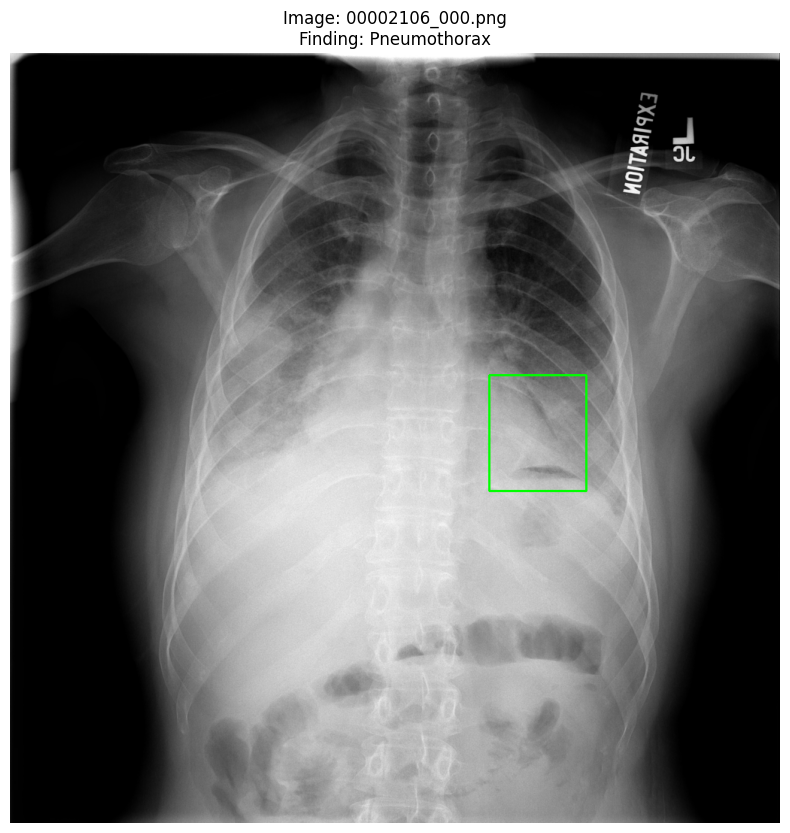

In [58]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Load the CSV file ---
bbox_csv_path = "/kaggle/input/data/BBox_List_2017.csv"

# Columns are separated by commas.
bbox_df = pd.read_csv(bbox_csv_path)

# Get the row index of the image we want to extract
row = bbox_df.iloc[872]
image_index = row["Image Index"]
finding_label = row["Finding Label"]

# CSV has separate columns for the bounding box coordinates:
# For example, columns: "Bbox [x", "y", "w", "h]"
x = float(row["Bbox [x"])
y = float(row["y"])
w = float(row["w"])
h = float(row["h]"])

print("Image Index:", image_index)
print("Finding Label:", finding_label)
print(f"Bounding Box: x={x}, y={y}, w={w}, h={h}")

# Define a helper function to load an image given its name
def load_image_by_name(image_name, base_dir, grayscale=False):
    """
    Searches through subfolders images_001/images, images_002/images, ..., images_012/images
    for the given image_name and loads the image.

    Parameters:
        image_name (str): The name of the image file (e.g. "00013118_008.png").
        base_dir (str): The parent directory that contains the subfolders.
        grayscale (bool): Whether to load the image in grayscale.

    Returns:
        image (np.array): The loaded image.

    Raises:
        FileNotFoundError: If the image is not found.
    """
    for i in range(1, 13):
        folder = os.path.join(base_dir, f"images_{i:03d}", "images")
        candidate = os.path.join(folder, image_name)
        if os.path.exists(candidate):
            if grayscale:
                img = cv2.imread(candidate, cv2.IMREAD_GRAYSCALE)
            else:
                img = cv2.imread(candidate, cv2.IMREAD_COLOR)
            return img
    raise FileNotFoundError(f"Image {image_name} not found in any subfolder.")

# Set your base directory (the parent folder containing images_001, images_002, ..., images_012)
img_base_dir = "/kaggle/input/data"

# Load the image
# In this example, we'll load the image in color.
img = load_image_by_name(image_index, img_base_dir, grayscale=False)

# Check that the image was loaded.
if img is None:
    raise ValueError(f"Failed to load image {image_index}.")

# Draw the bounding box
# Convert the bbox coordinates to integers.
x, y, w, h = int(x), int(y), int(w), int(h)
img_boxed = img.copy()

# Draw a green rectangle with thickness 2.
# Parameters:
# - First parameter: 'img_boxed' is the image (in BGR format) on which the rectangle will be drawn.
# - Second parameter: (x, y) represents the top-left corner of the rectangle.
# - Third parameter: (x + w, y + h) represents the bottom-right corner of the rectangle.
#       - Here, 'w' is the width and 'h' is the height of the bounding box.
# - Fourth parameter: (0, 255, 0) specifies the color of the rectangle in BGR format.
#       - 0 for blue, 255 for green, 0 for red results in a green rectangle.
# - Fifth parameter: 2 is the thickness of the rectangle border in pixels.
cv2.rectangle(img_boxed, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Display the image with the bounding box
plt.figure(figsize=(10, 10))

# Convert BGR (used by OpenCV) to RGB for displaying with matplotlib.
plt.imshow(cv2.cvtColor(img_boxed, cv2.COLOR_BGR2RGB))
plt.title(f"Image: {image_index}\nFinding: {finding_label}")
plt.axis("off")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import math

######################################
# 1. Image Loading Function
######################################
def load_image_by_name(image_name, base_dir, grayscale=False):
    """
    Searches through subfolders (images_001/images, images_002/images, ..., images_012/images)
    for the specified image_name and loads the image using PIL.

    Parameters:
      image_name (str): The filename of the image (e.g., "00027441_002.png").
      base_dir (str): The parent directory containing subfolders like images_001, etc.
      grayscale (bool): If True, converts the image to grayscale.

    Returns:
      img (PIL.Image): The loaded image.

    Raises:
      FileNotFoundError: If the image is not found.
    """
    from PIL import Image
    for i in range(1, 13):
        folder = os.path.join(base_dir, f"images_{i:03d}", "images")
        candidate = os.path.join(folder, image_name)
        if os.path.exists(candidate):
            img = Image.open(candidate)
            img = img.convert("L") if grayscale else img.convert("RGB")
            return img
    raise FileNotFoundError(f"Image {image_name} not found in any subfolder.")

######################################
# 2. Define Test Transform
######################################
# Resize the image to 224x224, convert to tensor, and normalize to mean 0.5, std 0.5.
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

######################################
# 3. Feature Map Extraction
######################################
def get_feature_maps(image, model, target_layer):
    """
    Feeds the input image through the model layer-by-layer until reaching the target layer.

    Mathematically, if the model's layers produce an output:
      F ∈ ℝ^(1×N×H'×W')
    this function returns F at the target layer.

    Parameters:
      image (torch.Tensor): Input image tensor of shape [1, C, H, W].
      model (nn.Module): The model containing a list of layers in model.layers.
      target_layer (int): The index of the layer to extract feature maps from.

    Returns:
      feature_maps (torch.Tensor): The tensor of feature maps from the target layer.
    """
    x = image.clone()
    feature_maps = None
    for idx, layer in enumerate(model.layers):
        x = layer(x)
        # When we reach the target layer, store the feature maps.
        if idx == target_layer:
            feature_maps = x
            break
    if feature_maps is None:
        raise ValueError("Target layer index is out of range!")
    return feature_maps

######################################
# 4. Compute Heatmap from Feature Maps
######################################
def compute_heatmap(feature_maps):
    """
    Computes a 2D heatmap from the feature maps using the maximum activation
    over all channels at each spatial location.

    Mathematically:
      h_max(i,j) = max_{c=1,...,N} F(0, c, i, j)
    where F is the feature map tensor of shape [1, N, H, W].

    Returns:
      heatmap (np.array): A 2D numpy array of shape [H, W] with raw activation values.
    """
    # Use the maximum operator over the channel dimension.
    # This selects, for each spatial location (i,j), the maximum value over all channels.
    heatmap = torch.max(feature_maps, dim=1)[0]  # shape: [1, H, W]
    heatmap = heatmap.squeeze(0).cpu().detach().numpy()  # Convert to 2D numpy array.
    return heatmap

######################################
# 5. Generate Union Bounding Box from Heatmap
######################################
def generate_union_bounding_box(heatmap, thresholds=[60, 180], target_size=(224,224)):
    """
    Processes the heatmap to generate a union bounding box that covers all
    active regions.

    Steps:
    a. Scale the normalized heatmap (values in [0,1]) to the [0,255] range:
       H_scaled(i,j) = 255 * h(i,j)
    b. For each threshold T in 'thresholds', create a binary map B_T where:
       B_T(i,j) = 255 if H_scaled(i,j) ≥ T, else 0.
    c. Combine these binary maps using a bitwise OR to form a combined binary map B.
    d. Use contour detection on B to obtain contours, where each contour is a list
       of points outlining a connected region.
    e. Compute the union bounding box by taking the min and max coordinates among all contours:
       BBox_heatmap = (x_min, y_min, x_max - x_min, y_max - y_min).
    f. Scale this bounding box from heatmap space to target image space using scale factors:
       scale_x = target_width / heatmap_width, scale_y = target_height / heatmap_height.

    Parameters:
      heatmap (np.array): 2D array with values in [0,1].
      thresholds (list): List of threshold values (on the 0–255 scale) to use.
      target_size (tuple): The dimensions (width, height) of the target image.

    Returns:
      bbox_scaled (tuple or None): The bounding box (x, y, w, h) in target image coordinates.
      heatmap_scaled (np.array): The heatmap scaled to [0,255].
      combined (np.array): The combined binary map.
    """
    # Scale the heatmap to [0,255]
    heatmap_scaled = (heatmap * 255).astype(np.uint8)

    binary_maps = []
    # For each threshold, threshold the heatmap to create a binary map.
    for thresh in thresholds:
        _, binary = cv2.threshold(heatmap_scaled, thresh, 255, cv2.THRESH_BINARY)
        binary_maps.append(binary)

    # Combine binary maps using bitwise OR: a pixel is active if it meets any threshold.
    combined = binary_maps[0]
    for binary in binary_maps[1:]:
        combined = cv2.bitwise_or(combined, binary)

    # Find contours in the combined binary map.
    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None, heatmap_scaled, combined

    # Compute the union bounding box that covers all contours.
    x_min, y_min = np.inf, np.inf
    x_max, y_max = -np.inf, -np.inf
    for cnt in contours:
        # For each contour, compute its bounding rectangle.
        x, y, w, h = cv2.boundingRect(cnt)
        # Update union bounds.
        x_min = min(x_min, x)
        y_min = min(y_min, y)
        x_max = max(x_max, x + w)
        y_max = max(y_max, y + h)
    bbox = (x_min, y_min, x_max - x_min, y_max - y_min)

    # Scale the bounding box from heatmap space to target image space.
    heatmap_h, heatmap_w = heatmap.shape  # e.g., 8x8
    target_w, target_h = target_size      # e.g., 224x224
    scale_x = target_w / heatmap_w
    scale_y = target_h / heatmap_h
    bbox_scaled = (int(x_min * scale_x), int(y_min * scale_y), int((x_max - x_min) * scale_x), int((y_max - y_min) * scale_y))

    return bbox_scaled, heatmap_scaled, combined

######################################
# 6. Draw Bounding Box on Image
######################################
def draw_bounding_box(image_np, bbox, color=(0, 255, 0), thickness=2):
    """
    Draws the bounding box on the provided image.

    Parameters:
      image_np (np.array): The input image (in BGR or grayscale).
      bbox (tuple): (x, y, w, h) bounding box.
      color (tuple): The color of the box (default is green).
      thickness (int): The thickness of the rectangle.

    Returns:
      image_with_box (np.array): The image with the bounding box drawn.
    """
    # Convert grayscale image to BGR if necessary.
    if len(image_np.shape) == 2 or image_np.shape[2] == 1:
        image_np = cv2.cvtColor(image_np, cv2.COLOR_GRAY2BGR)
    x, y, w, h = bbox
    cv2.rectangle(image_np, (x, y), (x+w, y+h), color, thickness)
    return image_np

######################################
# 7. Convert Tensor to NumPy Image
######################################
def tensor_to_image(tensor, mean=0.5, std=0.5):
    """
    Converts a PyTorch tensor (assumed shape [1, C, H, W]) to a NumPy image.
    The normalization is reversed (i.e., x = x * std + mean) and scaled to [0,255].

    Returns:
      image (np.array): The resulting image in uint8 format.
    """
    image = tensor.squeeze(0).cpu().detach().numpy()  # shape: [C, H, W]
    if image.shape[0] == 1:
        image = image[0]
    image = image * std + mean
    image = (image * 255).clip(0, 255).astype(np.uint8)
    return image

######################################
# 8. Main Process: GradCAM & Bounding Box Generation
######################################

# Specify the image name to process.
image_name = "00012094_047.png"

# Set the base directory where the subfolders (images_001, ..., images_012) are located.
img_base_dir = "/kaggle/input/data"

# Load the image. We assume chest X-rays are grayscale.
input_img = load_image_by_name(image_name, img_base_dir, grayscale=True)

# Apply the test transform to resize, convert to tensor, and normalize.
input_tensor = test_transform(input_img).unsqueeze(0).to(device)  # Now shape: [1, 1, 224, 224]

# Set the model to evaluation mode.
my_resnet.eval()

# Choose a target layer for GradCAM (e.g., the last convolutional block before pooling).
"""
Layer 0-3: Initial processing (convolution, normalization, ReLU, and pooling) to extract low-level features and reduce spatial size.
Layer 4: First residual block (maintains spatial dimensions, 64 channels).
Layer 5: Second residual block (downsampling; increases channels to 128).
Layer 6: Third residual block (further downsampling; increases channels to 256) — this is the ideal "target_layer" for localization because it retains spatial structure while capturing high-level features.
Layer 7-9: Global pooling, flattening, and fully connected layer that produce the final class scores (losing spatial information).
"""
target_layer = 6  # This corresponds to the third ResNet block output.

# Extract the feature maps from the target layer.
feature_maps = get_feature_maps(input_tensor, my_resnet, target_layer)

# Compute a heatmap from the feature maps using the max operator over channels.
heatmap = compute_heatmap(feature_maps)

# Normalize the heatmap to the [0,1] range:
if np.max(heatmap) > 0:
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))
else:
    heatmap = np.zeros_like(heatmap)

# Generate a union bounding box from the heatmap.
bbox_scaled, heatmap_scaled, binary_map = generate_union_bounding_box(heatmap, thresholds=[180], target_size=(224,224))
print("Generated union bounding box:", bbox_scaled)

# Convert the input tensor back to a NumPy image (in its original normalized scale).
orig_image = tensor_to_image(input_tensor, mean=0.5, std=0.5)  # Expected shape: [224,224]

# Draw the bounding box on the original image.
if bbox_scaled is not None:
    boxed_image = draw_bounding_box(orig_image.copy(), bbox_scaled, color=(0,255,0), thickness=2)
else:
    boxed_image = orig_image.copy()

######################################
# 9. Display the Results
######################################
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("GradCAM Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Combined Binary Map")
plt.imshow(binary_map, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Image with Bounding Box")
plt.imshow(boxed_image, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from tqdm import tqdm  # progress bar

# Set the model to evaluation mode so that layers like dropout and batch norm work in inference mode.
my_resnet.eval()  # This ensures the model does not update internal states and uses learned parameters.

# Initialize empty lists to store the ground truth labels and the model's predicted probabilities.
all_labels = []  # Will store true binary labels for each sample.
all_probs = []   # Will store predicted probability scores for each sample and each class.

# Explanation of expected shapes:
# - Suppose the test_loader has a batch size of B.
# - Each batch from test_loader returns:
#       images: a tensor of shape [B, C, H, W]
#       labels: a tensor of shape [B, num_classes]
#   For example, if B=32, C=1 (grayscale), H=W=224, and num_classes=15, then:
#       images.shape = [32, 1, 224, 224]
#       labels.shape = [32, 15]

# We use torch.no_grad() to disable gradient computations (this speeds up inference and reduces memory usage).
with torch.no_grad():
    # Iterate over the test set loader. Each iteration gives a batch of images and their corresponding labels.
    for images, labels in tqdm(test_loader):
        # Move the images and labels to the appropriate device (e.g., GPU or CPU).
        images, labels = images.to(device), labels.to(device)
        # At this point:
        #   images has shape: [B, 1, 224, 224]
        #   labels has shape: [B, 15] (for a 15-class problem)

        # Forward pass: compute the raw outputs (logits) of the model for the batch of images.
        outputs = my_resnet(images)

        # Remember the output are logits
        # outputs = tensor([
        #     [ 1.2, -0.5, 0.3, ..., 0.8],
        #     [ 0.7,  1.1, -0.2, ..., 0.4],
        #     ...
        #     [ 0.3,  0.0, 1.5, ..., -0.7]
        # ])
        # Shape: [32, 15]

        # For BCEWithLogitsLoss, the model outputs raw logits.
        # We apply the sigmoid function to convert logits to probabilities in the range [0,1].
        probs = torch.sigmoid(outputs)

        # probs = tensor([
        # [0.768, 0.377, 0.575, ..., 0.689],
        # [0.668, 0.750, 0.450, ..., 0.598],
        # ...
        # [0.574, 0.500, 0.817, ..., 0.331]
        # ])
        # Shape: [B, 15]

        # Move the labels and predicted probabilities back to CPU and convert them to NumPy arrays.
        # This is necessary for further evaluation (e.g., computing ROC curves) using NumPy and scikit-learn.
        # If we are iterating over test_loader, then we have [X, B, 15] where X is the number of batches in the dataloder
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

# After iterating over all batches, concatenate the lists along the first axis to get a complete dataset.
# If there are N samples in total under X batches, then:
#   all_labels becomes a NumPy array of shape [N, 15]
#   all_probs becomes a NumPy array of shape [N, 15]
all_labels = np.concatenate(all_labels, axis=0)  # Final shape: [num_samples, num_classes]
all_probs = np.concatenate(all_probs, axis=0)    # Final shape: [num_samples, num_classes]

# Determine the number of classes by examining the second dimension of all_labels.
num_classes = all_labels.shape[1]

100%|██████████| 289/289 [06:38<00:00,  1.38s/it]


Class: Atelectasis - AUC: 0.7171
Class: Cardiomegaly - AUC: 0.8732
Class: Consolidation - AUC: 0.7159
Class: Edema - AUC: 0.8274
Class: Effusion - AUC: 0.8033
Class: Emphysema - AUC: 0.7091
Class: Fibrosis - AUC: 0.7479
Class: Hernia - AUC: 0.8779
Class: Infiltration - AUC: 0.6739
Class: Mass - AUC: 0.7180
Class: No Finding - AUC: 0.7294
Class: Nodule - AUC: 0.6478
Class: Pleural_Thickening - AUC: 0.7043
Class: Pneumonia - AUC: 0.6796
Class: Pneumothorax - AUC: 0.7801


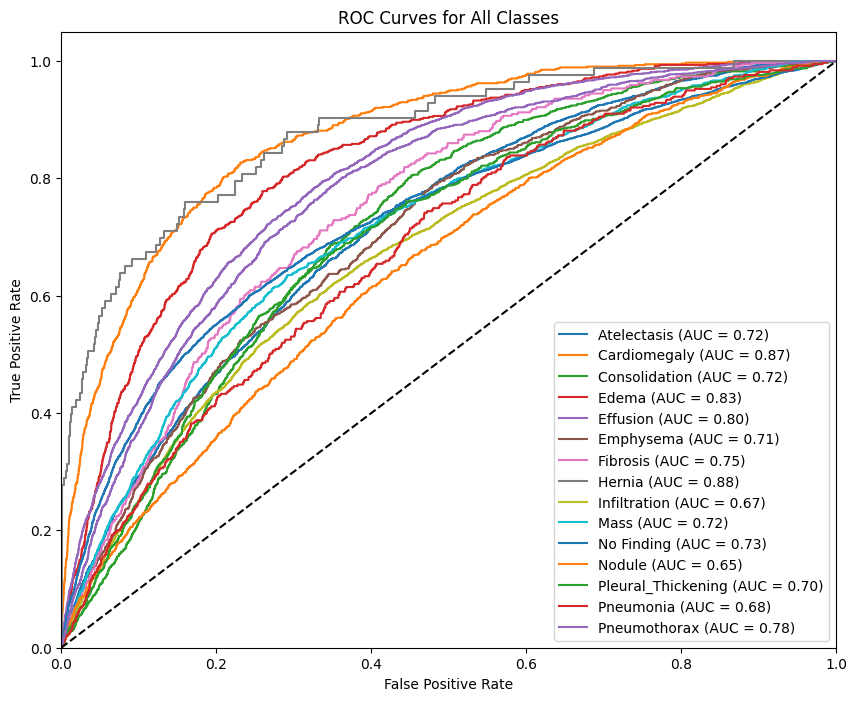

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Assume that:
# - all_labels: a NumPy array of shape [num_samples, 15] containing ground truth binary labels.
# - all_probs: a NumPy array of the same shape containing the predicted probabilities (0 to 1).

# For example, these arrays might look like:
#
# all_labels =
#  [[1, 0, 0, ..., 0],
#   [0, 1, 0, ..., 0],
#   ...,
#   [1, 0, 1, ..., 0]]
# So when I do all_labels[: 0] it will print out array([1, 0, ..., 1]), it will get all the labels for the first disease type for each sample

# all_probs =
#  [[0.72, 0.87, 0.71, ..., 0.78],
#   [0.65, 0.92, 0.68, ..., 0.80],
#   ...,
#   [0.75, 0.88, 0.73, ..., 0.77]]
# So when I do all_probs[: 0] it will print out array([0.72, 0.65, ..., 0.75]), it will get all the probabilities for the first disease type for each sample

# - unique_labels is a list of class names.
# - num_classes is the total number of classes.

# We will compute the ROC curve for each class separately.
# The ROC curve plots True Positive Rate (TPR) versus False Positive Rate (FPR) for various threshold values.
# Mathematically:
#     TPR = Recall = TP / (TP + FN)
#     FPR = FP / (FP + TN)
# And the ROC curve is generated by varying the threshold from 0 to 1.
# AUC (Area Under the Curve) summarizes the ROC curve with a single value between 0 and 1.
# A value near 1 indicates that the classifier is very good at ranking positives above negatives.

# Dictionaries to store the computed FPR, TPR, and AUC for each class.
fpr = {}      # False Positive Rates per class
tpr = {}      # True Positive Rates per class
roc_auc = {}  # AUC score per class

# Loop over each class (i.e., treat each class as a binary problem)
for i in range(num_classes):
    # roc_curve calculates:
    # - fpr[i]: array of false positive rates for class i at different thresholds.
    # - tpr[i]: array of true positive rates (recall) for class i.
    # - _ : the thresholds used (we don't need to store them here).
    fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])

    # roc_auc_score calculates the area under the ROC curve for class i.
    # A higher AUC means the classifier is better at distinguishing positive from negative cases.
    roc_auc[i] = roc_auc_score(all_labels[:, i], all_probs[:, i])

    # Print the AUC for the current class, which answers: "Of all diseased patients, how many did we detect?"
    print(f"Class: {unique_labels[i]} - AUC: {roc_auc[i]:.4f}")

# Plot the ROC curves for all classes on the same figure.
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    # Plot the ROC curve for class i.
    # The x-axis is the FPR and the y-axis is the TPR.
    plt.plot(fpr[i], tpr[i], label=f"{unique_labels[i]} (AUC = {roc_auc[i]:.2f})")

# Plot the diagonal line, which represents random guessing:
# At any threshold, if TPR equals FPR, the model is doing no better than chance.
plt.plot([0, 1], [0, 1], 'k--')  # 'k--' means a black dashed line

# Set plot limits for clarity.
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Label the axes.
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Set the title of the plot.
plt.title('ROC Curves for All Classes')

# Add a legend to indicate which line corresponds to which class and its AUC.
plt.legend(loc="lower right")

# Display the ROC curve plot.
plt.show()